In [3]:
import pandas as pd
import numpy as np
df=pd.read_csv(r"C:\Users\jidub\OneDrive\Documents\resume\projects\analyst\healthcare\healthcare_dataset.csv")

In [5]:
df.head()

,Name,Age,Gender,Blood Type,Medical Condition,Date of Admission,Doctor,Hospital,Insurance Provider,Billing Amount,Room Number,Admission Type,Discharge Date,Medication,Test Results
0,Bobby JacksOn,30,Male,B-,Cancer,2024-01-31,Matthew Smith,Sons and Miller,Blue Cross,18856.281306,328,Urgent,2024-02-02,Paracetamol,Normal
1,LesLie TErRy,62,Male,A+,Obesity,2019-08-20,Samantha Davies,Kim Inc,Medicare,33643.327287,265,Emergency,2019-08-26,Ibuprofen,Inconclusive
2,DaNnY sMitH,76,Female,A-,Obesity,2022-09-22,Tiffany Mitchell,Cook PLC,Aetna,27955.096079,205,Emergency,2022-10-07,Aspirin,Normal
3,andrEw waTtS,28,Female,O+,Diabetes,2020-11-18,Kevin Wells,"Hernandez Rogers and Vang,",Medicare,37909.782410,450,Elective,2020-12-18,Ibuprofen,Abnormal
4,adrIENNE bEll,43,Female,AB+,Cancer,2022-09-19,Kathleen Hanna,White-White,Aetna,14238.317814,458,Urgent,2022-10-09,Penicillin,Abnormal


In [7]:
print(df.head())
print(df.info())
print(df.describe())

            Name  Age  Gender Blood Type Medical Condition Date of Admission  \
0  Bobby JacksOn   30    Male         B-            Cancer        2024-01-31   
1   LesLie TErRy   62    Male         A+           Obesity        2019-08-20   
2    DaNnY sMitH   76  Female         A-           Obesity        2022-09-22   
3   andrEw waTtS   28  Female         O+          Diabetes        2020-11-18   
4  adrIENNE bEll   43  Female        AB+            Cancer        2022-09-19   

             Doctor                    Hospital Insurance Provider  \
0     Matthew Smith             Sons and Miller         Blue Cross   
1   Samantha Davies                     Kim Inc           Medicare   
2  Tiffany Mitchell                    Cook PLC              Aetna   
3       Kevin Wells  Hernandez Rogers and Vang,           Medicare   
4    Kathleen Hanna                 White-White              Aetna   

   Billing Amount  Room Number Admission Type Discharge Date   Medication  \
0    18856.281306    

In [9]:
print(df.isnull().sum())

Name                  0
Age                   0
Gender                0
Blood Type            0
Medical Condition     0
Date of Admission     0
Doctor                0
Hospital              0
Insurance Provider    0
Billing Amount        0
Room Number           0
Admission Type        0
Discharge Date        0
Medication            0
Test Results          0
dtype: int64


In [11]:
df['Date of Admission']=pd.to_datetime(df['Date of Admission'])
df['Discharge Date']=pd.to_datetime(df['Discharge Date'])


In [13]:
df['Stay_Days']=(df['Discharge Date'] - df['Date of Admission']).dt.days

In [17]:
bins=[0,10,35,50,65,100]
labels = ['Child','Young Adult','Adult','Middle Age','Senior']
df['Age_Group']= pd.cut(df['Age'], bins=bins, labels=labels)

In [19]:
df['Billing_Category']=pd.cut(df['Billing Amount'], bins=3, labels=['Low','Medium','High'])

In [21]:
df['Gender'].value_counts()

Gender
Male      27774
Female    27726
Name: count, dtype: int64

In [23]:
df['Medical Condition'].value_counts().head(10)

Medical Condition
Arthritis       9308
Diabetes        9304
Hypertension    9245
Obesity         9231
Cancer          9227
Asthma          9185
Name: count, dtype: int64

In [25]:
df.groupby('Medical Condition')['Billing Amount'].mean()

Medical Condition
Arthritis       25497.327056
Asthma          25635.249359
Cancer          25161.792707
Diabetes        25638.405577
Hypertension    25497.095761
Obesity         25805.971259
Name: Billing Amount, dtype: float64

In [29]:
df['Admission Type'].value_counts()

Admission Type
Elective     18655
Urgent       18576
Emergency    18269
Name: count, dtype: int64

In [33]:
df['Stay_Days'].mean()

15.50900900900901

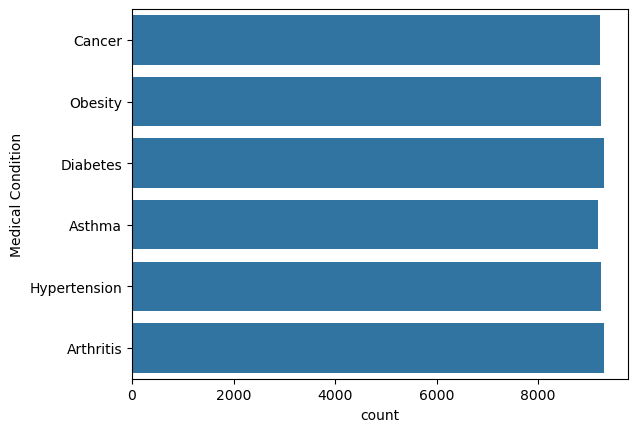

In [35]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.countplot(data=df, y='Medical Condition')
plt.show()

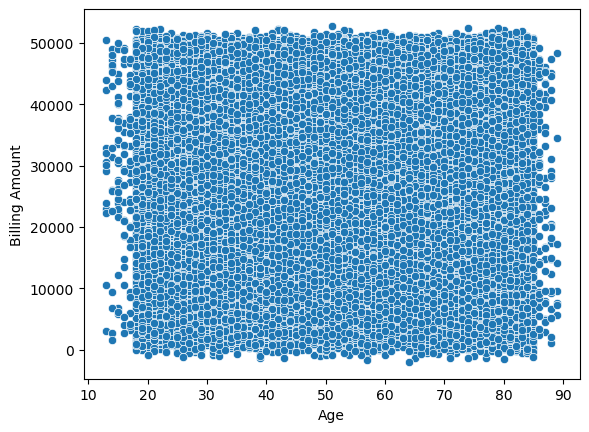

In [41]:
sns.scatterplot(x='Age', y='Billing Amount', data=df)
plt.show()

In [47]:
df.to_csv("healthcare_cleaned_for_sql.csv", index=False)

In [53]:
import pandas as pd

file_path = r"C:\Users\jidub\Downloads\clean_healthcare_data.xls"

df = pd.read_excel(file_path, engine="xlrd")

df.to_csv("healthcare_dataset.csv", index=False)

print("Conversion successful!")

ImportError: Missing optional dependency 'xlrd'. Install xlrd >= 2.0.1 for xls Excel support Use pip or conda to install xlrd.